In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir 
import muon as mu

In [2]:
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white")

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==2.0.2 scipy==1.14.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.5 pynndescent==0.5.13


In [3]:
mdata = mu.read("/Users/jerryaaaaaa/tcr_model_2.h5mu")

/opt/miniconda3/lib/python3.12/site-packages/anndata/utils.py:334: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


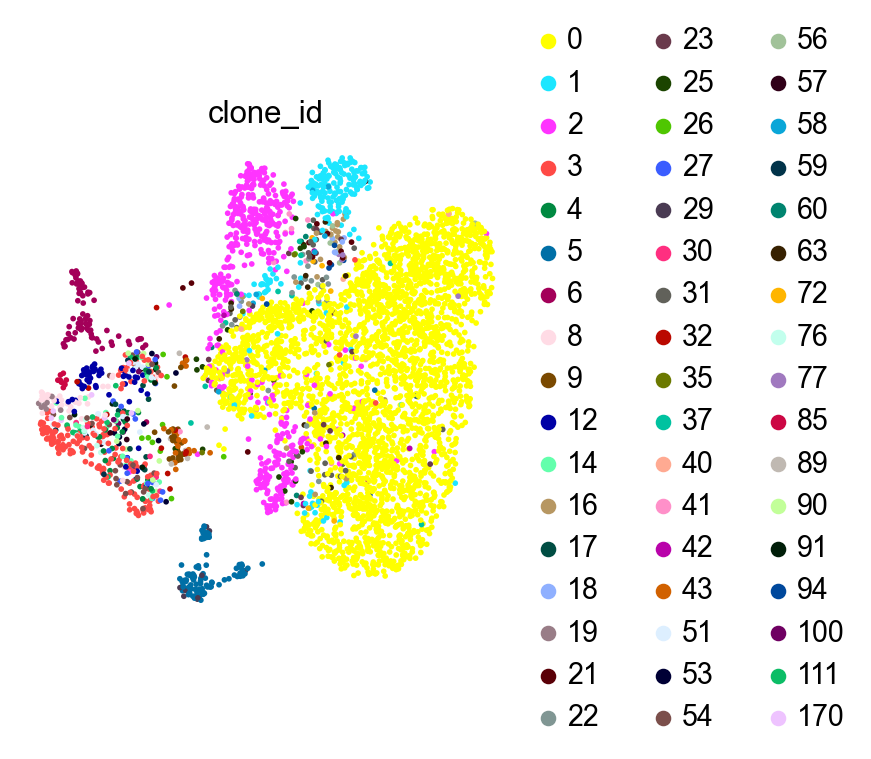

In [4]:
sc.pl.umap(mdata["gex"], color="clone_id", frameon=False)

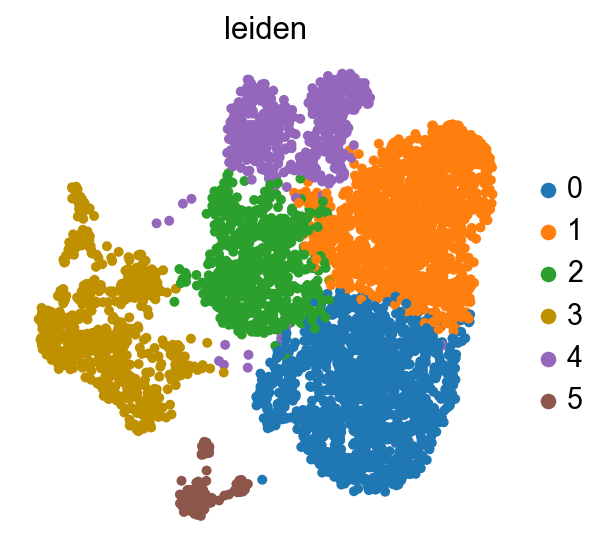

In [6]:
sc.pl.umap(mdata["gex"], 
           color="leiden", 
           palette=["#1f77b4", "#ff7f0e", "#2ca02c", "#BF9000", "#9467bd", "#8c564b"],
           size=80, 
           frameon=False)

In [6]:
sc.tl.rank_genes_groups(mdata["gex"], groupby="leiden", method="wilcoxon")

ranking genes


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:04)


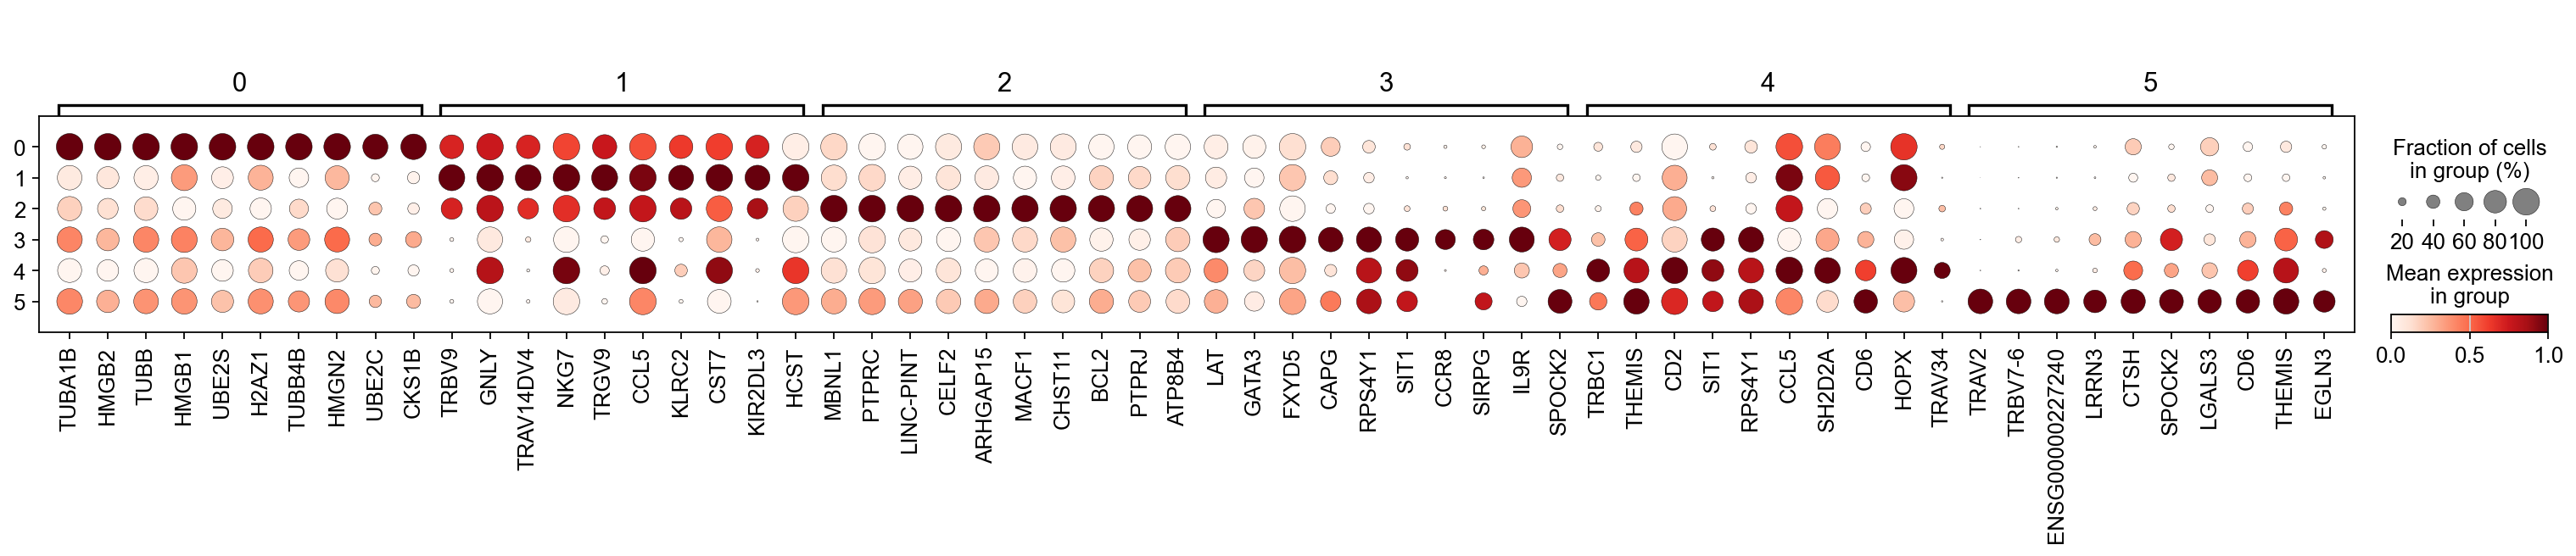

In [7]:
sc.pl.rank_genes_groups_dotplot(
    mdata["gex"], n_genes=10, standard_scale="var", dendrogram=False
)

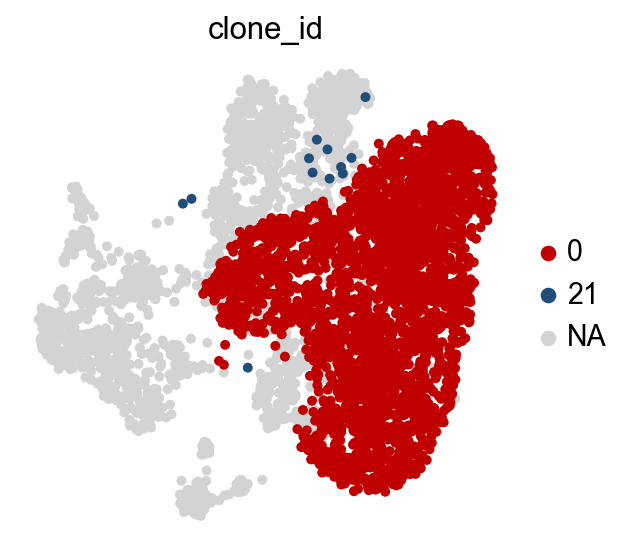

In [8]:
sc.pl.umap(mdata["gex"], 
           color="clone_id",
           groups=["0", "21"],
           palette=["#C00000", "#1F4E79"],
           size=80, 
           frameon=False)

In [21]:
sc.tl.rank_genes_groups(mdata["gex"], "clone_id", groups=["0"], reference="21", method="wilcoxon")
deg_all = sc.get.rank_genes_groups_df(mdata["gex"], group="0")

ranking genes
--> Few observations in a group for normal approximation (<=25). Lower test accuracy.
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)


In [74]:
deg_filtered = deg_all[
    (deg_all["pvals_adj"] < 0.05) & (deg_all["logfoldchanges"].abs() > 0.25)
]

In [75]:
deg_all.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj
0,TRBV9,5.965532,7.171411,2.438377e-09,0.000013
1,TRAV14DV4,5.924119,32.134842,3.139774e-09,0.000014
2,TRGV9,5.843369,5.888486,5.115537e-09,0.000019
3,KIR2DL3,5.718261,31.568108,1.076198e-08,0.000034
4,IKZF2,5.641325,31.560968,1.687472e-08,0.000046
5,TRAV8-4,5.175546,30.591875,2.272455e-07,0.000453
6,ITGB1,4.720858,3.012889,2.348523e-06,0.003964
7,TRGV4,4.641149,29.997524,3.464780e-06,0.005316
8,HLA-DRA,4.461630,2.788764,8.133867e-06,0.011154
9,KIR2DS4,4.399595,5.709929,1.084529e-05,0.013968


In [76]:
deg_filtered.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,TRBV9,5.965532,7.171411,2.438377e-09,0.000013
1,TRAV14DV4,5.924119,32.134842,3.139774e-09,0.000014
2,TRGV9,5.843369,5.888486,5.115537e-09,0.000019
3,KIR2DL3,5.718261,31.568108,1.076198e-08,0.000034
4,IKZF2,5.641325,31.560968,1.687472e-08,0.000046
5,TRAV8-4,5.175546,30.591875,2.272455e-07,0.000453
6,ITGB1,4.720858,3.012889,2.348523e-06,0.003964
7,TRGV4,4.641149,29.997524,3.464780e-06,0.005316
8,HLA-DRA,4.461630,2.788764,8.133867e-06,0.011154
9,KIR2DS4,4.399595,5.709929,1.084529e-05,0.013968


In [77]:
deg_filtered.to_excel("/Users/jerryaaaaaa/clone_0vs21_DEG_2.xlsx")

In [41]:
mdata.obs

,gex:n_genes,gex:n_genes_by_counts,gex:total_counts,gex:total_counts_mt,gex:pct_counts_mt,gex:leiden,gex:clone_id,gex:clonal_dynamic_label,gex:clonal_dynamic,gex:expansion_fold,...,airr:clone_id_size,airr:clonal_dynamic_label,airr:clonal_dynamic,airr:expansion_fold,airr:alpha_cdr3_aa,airr:beta_cdr3_aa,airr:alpha_cdr3_len,airr:beta_cdr3_len,airr:enriched_tier,gex:clone_reactivity_score
AAACCTGAGAATGTTG-1,7719,7714,59153.0,276.0,0.466587,0,0,1.0,Enriched,18.141,...,2879,1.0,Enriched,18.141,AMPVVDLLTGGADGLT,ASSVEPQLAGRGDTQY,16,16,Tier_3,0.090527
AAACCTGAGGTAGCTG-1,3443,3443,9105.0,33.0,0.362438,1,0,1.0,Enriched,18.141,...,2879,1.0,Enriched,18.141,AMPVVDLLTGGADGLT,ASSVEPQLAGRGDTQY,16,16,Tier_3,0.090527
AAACCTGAGTAGATGT-1,3740,3740,11302.0,92.0,0.814015,4,1,1.0,Enriched,4.414,...,219,1.0,Enriched,4.414,APLGNEKLT,ASSYYRPTGPYEQY,9,14,Tier_4,0.286648
AAACCTGAGTGGAGTC-1,3287,3286,9576.0,55.0,0.574353,1,0,1.0,Enriched,18.141,...,2879,1.0,Enriched,18.141,AMPVVDLLTGGADGLT,ASSVEPQLAGRGDTQY,16,16,Tier_3,0.090527
AAACCTGCAGACAAGC-1,3016,3016,8776.0,100.0,1.139471,1,0,1.0,Enriched,18.141,...,2879,1.0,Enriched,18.141,AMPVVDLLTGGADGLT,ASSVEPQLAGRGDTQY,16,16,Tier_3,0.090527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACATCGACGC-1,1980,1980,4300.0,75.0,1.744186,1,0,1.0,Enriched,18.141,...,2879,1.0,Enriched,18.141,AMPVVDLLTGGADGLT,ASSVEPQLAGRGDTQY,16,16,Tier_3,0.090527
TTTGTCAGTTGGAGGT-1,5410,5409,26259.0,232.0,0.883507,0,0,1.0,Enriched,18.141,...,2879,1.0,Enriched,18.141,AMPVVDLLTGGADGLT,ASSVEPQLAGRGDTQY,16,16,Tier_3,0.090527
TTTGTCATCACAACGT-1,6239,6238,30520.0,238.0,0.779817,3,111,1.0,Enriched,104.145,...,12,1.0,Enriched,104.145,ATVPMFSGGYNKLI,ASTLLRGEQF,14,10,Tier_2,-0.611930
TTTGTCATCCAAATGC-1,2543,2542,4771.0,110.0,2.305596,3,3,1.0,Enriched,164.062,...,172,1.0,Enriched,164.062,ATQLYNARLM,ASSARGTKNIQY,10,12,Tier_2,-0.380814


In [43]:
clone_cluster_percentage = (pd.crosstab(
    index = mdata.obs["gex:clone_id"],
    columns = mdata.obs["gex:leiden"],
    normalize = "index",
    ) * 100
)

In [44]:
print(clone_cluster_percentage.round(2))

gex:leiden        0      1      2       3       4      5
gex:clone_id                                            
0             38.49  44.49  16.92    0.00    0.10   0.00
1              8.68   4.11  14.61    0.00   72.60   0.00
2             26.54   1.03  19.55    0.41   52.47   0.00
3              0.58   1.16   0.00   98.26    0.00   0.00
4              0.00   0.00   0.00  100.00    0.00   0.00
5              3.12   0.00   0.00    0.00    0.00  96.88
6              0.00   0.00   0.00  100.00    0.00   0.00
8              0.00   0.00   0.00  100.00    0.00   0.00
9              0.00   0.00  12.00   88.00    0.00   0.00
12             0.00   0.00   0.00  100.00    0.00   0.00
14             0.00   0.00   0.00  100.00    0.00   0.00
16            16.00   4.00  16.00    0.00   64.00   0.00
17             0.00   0.00   0.00  100.00    0.00   0.00
18             0.00   0.00  28.57    0.00   71.43   0.00
19             0.00   0.00  12.50   87.50    0.00   0.00
21             0.00   0.00   0.

In [11]:
import matplotlib.pyplot as plt

/opt/miniconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:916: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/miniconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:916: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/miniconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:916: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/miniconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:916: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

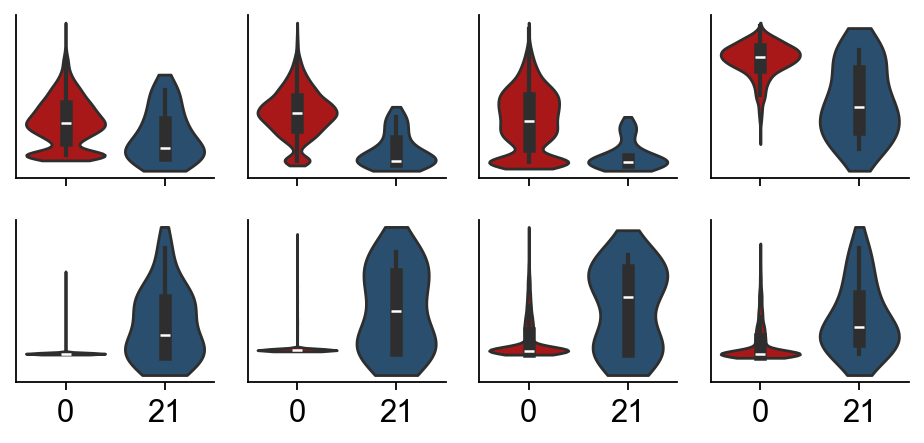

In [12]:
markers = ["NFATC2", "ITGB1", "MKI67", "GNLY", "PDCD1", "SIT1", "TIGIT", "GZMK"]
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(6, 3), sharex=True)
axes = axes.flatten()
order = ["0", "21"]

for i, gene in enumerate(markers):
    ax = axes[i]

    sc.pl.violin(
        mdata["gex"],
        keys=gene,
        groupby="clone_id",
        ax=axes[i],
        order=order,
        palette=["#C00000", "#1F4E79"],
        inner="box",
        cut=1,
        show=False,  # Keep plot open to allow matplotlib customization
        stripplot=False,  # Set to True if you want individual cell jitter dots
        use_raw=False,  # Set layer="log1p" or use_raw=True if needed
    )
    # Clean up individual plot aesthetics
    ax.set_xlabel("")  # Hide X-label on top row to avoid clutter
    ax.set_ylabel("")
    ax.set_yticks([])

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

# Adjust bottom row X-axis ticks for cluster labels
for ax in axes[4:]:
    ax.tick_params(axis="x")

plt.tight_layout()
plt.show()

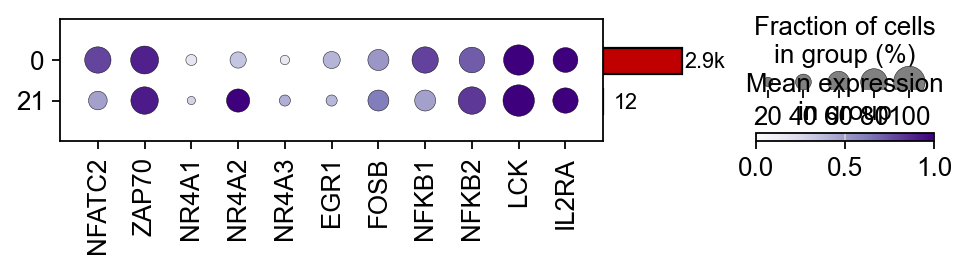

In [156]:
tcr_sig_markers = ["NFATC2", "ZAP70", "NR4A1", "NR4A2", "NR4A3", "EGR1", "FOSB", "NFKB1", "NFKB2", "LCK", "IL2RA"]
order = ["0", "21"]
dp = sc.pl.dotplot(mdata["gex"][mdata["gex"].obs["clone_id"].isin(order)], 
                   tcr_sig_markers, 
                   'clone_id',
                   vmax=1, 
                   vmin=0,
                   cmap="Purples",
                   figsize=(7, 1),
                   return_fig=True)
dp.add_totals(color=["#C00000", "#1F4E79"]).show()

In [ ]:
sc.pl.dotplot(mdata["gex"][mdata["gex"].obs["clone_id"].isin(order)], 
                   tcr_sig_markers, 
                   'clone_id', 
                   cmap="Purples",
                   vmax=1,
                   vmin=0,
                   return_fig=False)

In [86]:
vdjdb = ir.datasets.vdjdb()

python(2905) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Processing VDJDB entries:   0%|          | 0/140652 [00:00<?, ?it/s]

Converting to AnnData object
Filtering chains...
Indexing VJ chains...
Indexing VDJ chains...
build result array


In [87]:
ir.pp.ir_dist(mdata, vdjdb, metric="identity", sequence="aa")

Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.


In [118]:
ir.tl.ir_query(
    mdata,
    vdjdb,
    metric="identity",
    sequence="aa",
    receptor_arms="VDJ",
    dual_ir="primary_only"
)

Initializing lookup tables. 
--> Done initializing lookup tables. (0:00:02)
Computing clonotype x clonotype distances.
--> Done computing clonotype x clonotype distances.  (0:00:00)
Stored IR distance matrix in `adata.uns["ir_query_VDJDB_aa_identity"]`.


In [119]:
ir.tl.ir_query_annotate_df(
    mdata,
    vdjdb,
    metric="identity",
    sequence="aa",
    include_ref_cols=["antigen.species", "antigen.gene"],
)

,antigen.species,antigen.gene
AAGGTTCAGGCAAAGA-1,InfluenzaA,M
AAGGTTCAGGCAAAGA-1,CMV,pp65
AAGGTTCAGGCAAAGA-1,CMV,pp65
ACACCAAGTGTTTGGT-1,InfluenzaA,M
ACACCAAGTGTTTGGT-1,CMV,pp65
...,...,...
TTTATGCTCTAACGGT-1,EBV,BZLF1
TTTATGCTCTAACGGT-1,HomoSapiens,NY-ESO-1
TTTGCGCAGACCTAGG-1,InfluenzaA,M
TTTGCGCAGACCTAGG-1,CMV,pp65


In [120]:
ir.tl.ir_query_annotate(
    mdata,
    vdjdb,
    metric="identity",
    sequence="aa",
    include_ref_cols=["antigen.species"],
    strategy="most-frequent"
)

  0%|          | 0/66 [00:00<?, ?it/s]

Stored result in `mdata.obs["airr:antigen.species"]`.


/opt/miniconda3/lib/python3.12/site-packages/scirpy/tl/_ir_query.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return values[0]


In [121]:
mdata["gex"].obs["antigen.species"] = mdata["airr"].obs["antigen.species"]
mdata["gex"].obs["antigen.species"] = mdata["gex"].obs["antigen.species"].astype("category")
mdata["gex"].obs["antigen.species"] = mdata["gex"].obs["antigen.species"].cat.remove_unused_categories()

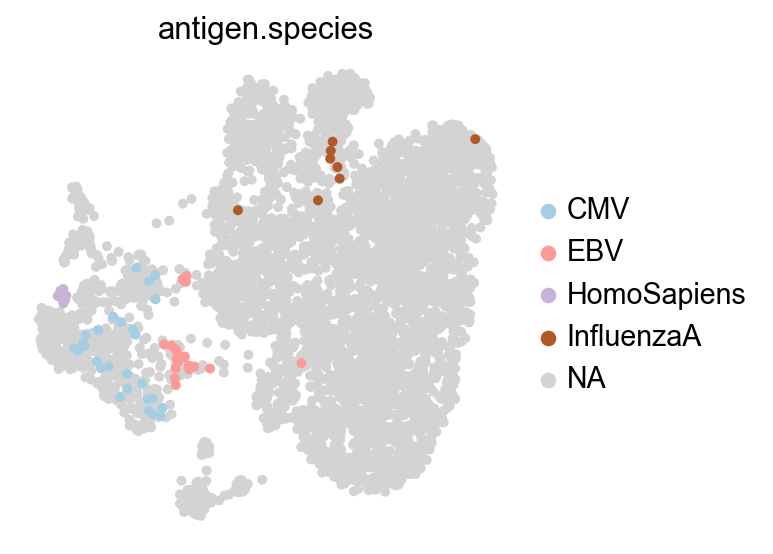

In [123]:
sc.pl.umap(mdata["gex"], color="antigen.species", size=80, frameon=False, palette="Paired")